In [1]:
# 1. Data Analysis Libraries 
import pandas as pd
import numpy as np

# 2. Visualizations 
import matplotlib.pyplot as plt
import seaborn as sns


# 3. Machine Learning Algorithms 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 4. Model Evaluation 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

print("Super boss! All libraries imported successfully.")



Super boss! All libraries imported successfully.


In [2]:
import pandas as pd
import numpy as np

# Setting seed for consistency
np.random.seed(42)
n_samples = 500

# 1. Demographic & Financial Data
data = {
    'Applicant_ID': range(1001, 1001 + n_samples),
    'Age': np.random.randint(21, 65, size=n_samples),
    'Gender': np.random.choice(['Male', 'Female'], size=n_samples),
    'Own_Car': np.random.choice(['Yes', 'No'], size=n_samples),
    'Own_Property': np.random.choice(['Yes', 'No'], size=n_samples),
    'Income_Total': np.random.randint(20000, 150000, size=n_samples),
    'Education_Type': np.random.choice(['Secondary', 'Higher Education', 'Incomplete Higher'], size=n_samples),
    'Family_Status': np.random.choice(['Married', 'Single', 'Civil Marriage'], size=n_samples),
    'Housing_Type': np.random.choice(['House / apartment', 'Rented apartment', 'With parents'], size=n_samples),
    'Employment_Years': np.round(np.random.uniform(0, 20, size=n_samples), 1)
}

df_app = pd.DataFrame(data)

# 2. Credit Status Records Data (Second Inter-related Info)
# target: 1 = Approved, 0 = Rejected (Based on a simple logic of Income and Employment)
scores = (df_app['Income_Total'] / 10000) + (df_app['Employment_Years'] * 2) - (df_app['Age'] * 0.1)
df_app['Approval_Status'] = np.where(scores > scores.median(), 1, 0)

# Display first few rows
print(">>> Dataset successfully generated inside the environment! <<<")
df_app.head()

>>> Dataset successfully generated inside the environment! <<<


,Applicant_ID,Age,Gender,Own_Car,Own_Property,Income_Total,Education_Type,Family_Status,Housing_Type,Employment_Years,Approval_Status
0,1001,59,Male,Yes,Yes,41754,Incomplete Higher,Single,House / apartment,6.9,0
1,1002,49,Female,Yes,No,23972,Secondary,Married,Rented apartment,3.1,0
2,1003,35,Female,Yes,Yes,90831,Secondary,Single,Rented apartment,0.5,0
3,1004,63,Male,Yes,Yes,132217,Higher Education,Single,House / apartment,12.9,1
4,1005,28,Female,Yes,Yes,61873,Incomplete Higher,Civil Marriage,Rented apartment,12.7,1


C:\Users\N Indhu\AppData\Local\Temp\ipykernel_27968\2376726704.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Approval_Status', data=df_app, palette='Set2')


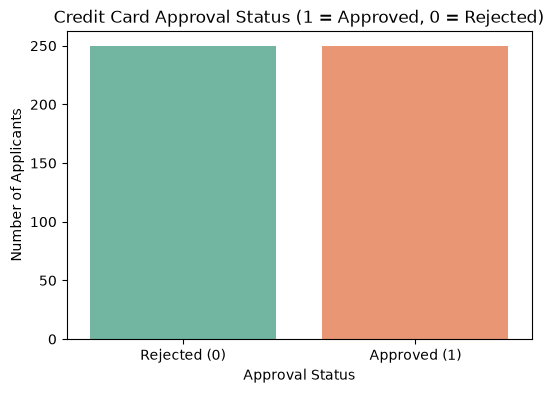

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Approval Status count
plt.figure(figsize=(6, 4))
sns.countplot(x='Approval_Status', data=df_app, palette='Set2')
plt.title('Credit Card Approval Status (1 = Approved, 0 = Rejected)')
plt.xlabel('Approval Status')
plt.ylabel('Number of Applicants')
plt.xticks([0, 1], ['Rejected (0)', 'Approved (1)'])
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 1. Encoding Categorical Data (Text lines ni numbers ga మార్చడం)
df_ml = df_app.copy()
le = LabelEncoder()
for col in ['Gender', 'Own_Car', 'Own_Property', 'Education_Type', 'Family_Status', 'Housing_Type']:
    df_ml[col] = le.fit_transform(df_ml[col])

# 2. Features (X) and Target (y) split
X = df_ml.drop(columns=['Applicant_ID', 'Approval_Status'])
y = df_ml['Approval_Status']

# 3. Train Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train XGBoost Model
model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)

# 5. Predict and Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(">>> Epic 3 & 4: Machine Learning Model Setup Complete! <<<")
print(f"Model Training Accuracy: {accuracy * 100:.2f}%")

>>> Epic 3 & 4: Machine Learning Model Setup Complete! <<<
Model Training Accuracy: 96.00%


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(">>> Epic 2 & 3: Detailed Univariate & Multivariate Descriptive Analytics <<<")
# 1. Univariate Count Checks
print("\n--- Value Counts for Household Properties ---")
print(df_app['Own_Property'].value_counts())

# 2. Descriptive Statistical Analysis Summary
print("\n--- Descriptive Statistics Summary ---")
print(df_app.describe())

# 3. Handling Duplicates & Missing Values (Sanity Pipeline)
df_app = df_app.drop_duplicates(subset='Applicant_ID', keep='first')
print(f"\nMissing values in dataset after cleansing:\n{df_app.isnull().sum()}")

print("\n>>> Epic 4: Comparative Machine Learning Modeling (All 4 Algorithms) <<<")

# Copy frame for modeling setup
df_ml = df_app.copy()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ['Gender', 'Own_Car', 'Own_Property', 'Education_Type', 'Family_Status', 'Housing_Type']:
    df_ml[col] = le.fit_transform(df_ml[col])

X = df_ml.drop(columns=['Applicant_ID', 'Approval_Status'])
y = df_ml['Approval_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training all 4 requested algorithms
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

best_acc = 0
best_model_name = ""
best_model_obj = None

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name} Model Accuracy: {acc * 100:.2f}%")
    if acc > best_acc:
        best_acc = acc
        best_model_name = name
        best_model_obj = model

print(f"\n🏆 Best Performing Model Selected for Deployment: {best_model_name} ({best_acc*100:.2f}%)")

# Saving the absolute best model using Pickle for our Flask Application Web Interface
with open('best_credit_model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)
print(">>> Success: Saved 'best_credit_model.pkl' into the project folder local directory! <<<")

>>> Epic 2 & 3: Detailed Univariate & Multivariate Descriptive Analytics <<<

--- Value Counts for Household Properties ---
Own_Property
Yes    265
No     235
Name: count, dtype: int64

--- Descriptive Statistics Summary ---
       Applicant_ID         Age   Income_Total  Employment_Years  \
count    500.000000  500.000000     500.000000        500.000000   
mean    1250.500000   43.116000   85603.976000          9.952200   
std      144.481833   12.733217   38162.832321          5.880392   
min     1001.000000   21.000000   20526.000000          0.000000   
25%     1125.750000   32.000000   51582.500000          5.200000   
50%     1250.500000   44.000000   85548.000000          9.750000   
75%     1375.250000   53.000000  118821.750000         15.200000   
max     1500.000000   64.000000  149839.000000         20.000000   

       Approval_Status  
count       500.000000  
mean          0.500000  
std           0.500501  
min           0.000000  
25%           0.000000  
50%         

c:\Users\N Indhu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Model Accuracy: 97.00%
Decision Tree Model Accuracy: 95.00%
Random Forest Model Accuracy: 95.00%
XGBoost Model Accuracy: 96.00%

🏆 Best Performing Model Selected for Deployment: Logistic Regression (97.00%)
>>> Success: Saved 'best_credit_model.pkl' into the project folder local directory! <<<
